In [1]:
%run stochastic_lite.ipynb

In [2]:
deltaF=0.25
segmentDuration=64

## Noise only

In [3]:
dat=np.load('../data/colored_noise_H1.npy')
t1,h1=dat[:,0],dat[:,1]
d1=TimeSeries(t1,h1)

dat=np.load('../data/colored_noise_H2.npy')
t2,h2=dat[:,0],dat[:,1]
d2=TimeSeries(t2,h2)

jobDuration=d2.times[-1]-d2.times[0]+d2.deltaT

In [4]:
nperseg=int(d1.Fs/deltaF)
freqs,P1_test = welch_psd(d1.data,nperseg=nperseg,window='Hann',fs=d1.Fs)
freqs,P2_test = welch_psd(d2.data,nperseg=nperseg,window='Hann',fs=d2.Fs)

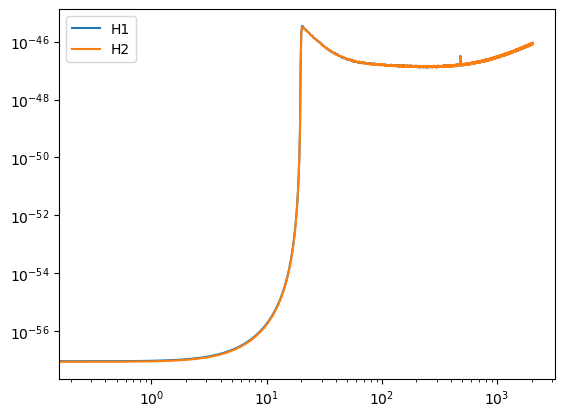

In [5]:
plt.loglog(freqs,P1_test,label='H1')
plt.loglog(freqs,P2_test,label='H2')
plt.legend()

In [6]:
Ys,sigs,Y_fs,var_fs,segmentStartTimes,freqs=stochastic(d1,
                                                       d2,
                                                       segmentDuration,
                                                       deltaF,
                                                       verbose=False,
                                                       doOverlap=True,
                                                       alpha=0,
                                                       fref=25,
                                                       orf_file=None)

/var/folders/h9/8jj76gb51nq2gjkzk76xh3l415264w/T/ipykernel_35141/1520427049.py:108: RuntimeWarning: divide by zero encountered in divide
  S0 = FrequencySeries(freqs, (3*H0**2)/(10*np.pi**2*freqs**3) )
/var/folders/h9/8jj76gb51nq2gjkzk76xh3l415264w/T/ipykernel_35141/1520427049.py:117: ComplexWarning: Casting complex values to real discards the imaginary part
  Ys[II],sigs[II] = calc_Y_sigma_from_Yf_varf(Y_f.data[1:],var_f.data[1:], freqs=freqs[1:], alpha=alpha, fref=fref)
/var/folders/h9/8jj76gb51nq2gjkzk76xh3l415264w/T/ipykernel_35141/1520427049.py:119: ComplexWarning: Casting complex values to real discards the imaginary part
  Y_fs[:,II],var_fs[:,II] = Y_f.data, var_f.data


In [7]:
# combine spectra over times

Y_f,var_f=postprocessing_spectra(Y_fs,var_fs,jobDuration,segmentDuration,
                                 deltaF,d1.deltaT)

/var/folders/h9/8jj76gb51nq2gjkzk76xh3l415264w/T/ipykernel_35141/2966287306.py:14: RuntimeWarning: invalid value encountered in divide
  Y_f_o = np.sum(Y_fs_odds / var_fs_odds,axis=1) / np.sum(1/var_fs_odds,axis=1)
/var/folders/h9/8jj76gb51nq2gjkzk76xh3l415264w/T/ipykernel_35141/2966287306.py:15: RuntimeWarning: divide by zero encountered in divide
  v_f_o = 1/np.sum(1/var_fs_odds,axis=1)
/var/folders/h9/8jj76gb51nq2gjkzk76xh3l415264w/T/ipykernel_35141/2966287306.py:17: RuntimeWarning: invalid value encountered in divide
  Y_f_e = np.sum(Y_fs_evens / var_fs_evens,axis=1) / np.sum(1/var_fs_evens,axis=1)
/var/folders/h9/8jj76gb51nq2gjkzk76xh3l415264w/T/ipykernel_35141/2966287306.py:18: RuntimeWarning: divide by zero encountered in divide
  v_f_e = 1/np.sum(1/var_fs_evens,axis=1)
/var/folders/h9/8jj76gb51nq2gjkzk76xh3l415264w/T/ipykernel_35141/2966287306.py:28: RuntimeWarning: invalid value encountered in subtract
  detC_f = C_f_oo*C_f_ee - C_f_oe**2
/var/folders/h9/8jj76gb51nq2gjkzk76xh3

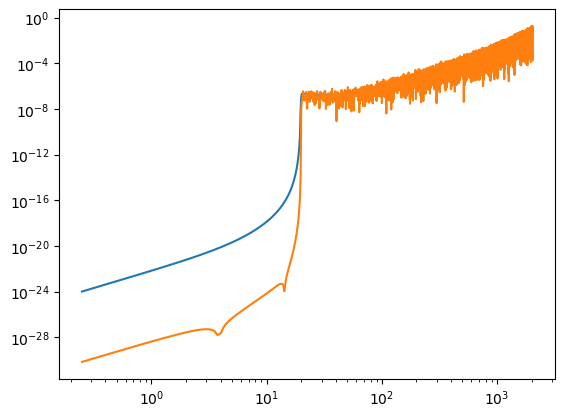

In [8]:
plt.loglog(freqs,np.sqrt(var_f))
plt.loglog(freqs,np.abs(Y_f))

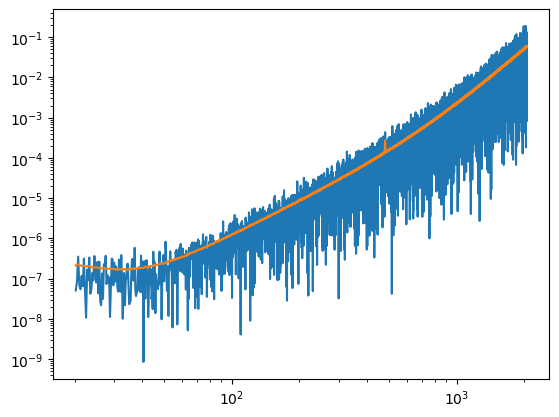

In [9]:
f_filter=freqs>20

plt.loglog(freqs[f_filter],np.abs(Y_f[f_filter]))
plt.loglog(freqs[f_filter],np.sqrt(var_f[f_filter]))


In [10]:
# compute optimal SNR

y,s=calc_Y_sigma_from_Yf_varf(np.real(Y_f[f_filter]),
                          var_f[f_filter],
                          freqs=freqs[f_filter],
                          alpha=2./3,
                          fref=25)

print('Optimal SNR [alpha=2/3]: %f'%(y/s))

Optimal SNR [alpha=2/3]: 0.135548


Text(0, 0.5, 'SNR')

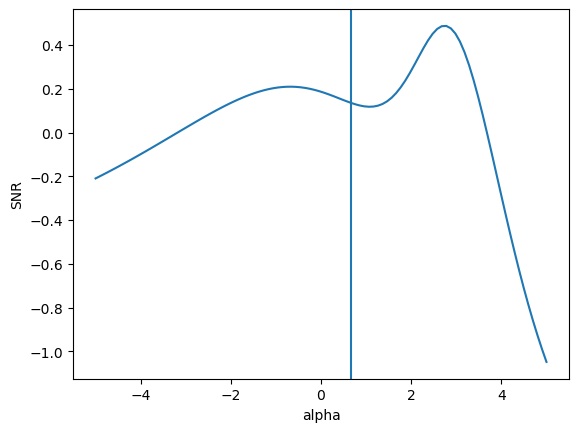

In [11]:
alphas=np.linspace(-5,5,100)

snrs=np.zeros(alphas.shape)
for ii,a in enumerate(alphas):
    y,s=calc_Y_sigma_from_Yf_varf(np.real(Y_f[f_filter]),
                          var_f[f_filter],
                          freqs=freqs[f_filter],
                          alpha=a,
                          fref=25)
    snrs[ii]=y/s
plt.plot(alphas,snrs)
plt.axvline(2./3)
plt.xlabel('alpha')
plt.ylabel('SNR')

14:42 bilby INFO    : Running for label 'GWB_powerlaw', output will be saved to 'outdir'
14:42 bilby INFO    : Analysis priors:
14:42 bilby INFO    : A=LogUniform(minimum=1e-08, maximum=0.001, name='A', latex_label='A', unit=None, boundary=None)
14:42 bilby INFO    : alpha=Uniform(minimum=-5, maximum=5, name='alpha', latex_label='alpha', unit=None, boundary=None)
14:42 bilby INFO    : Analysis likelihood class: <class '__main__.BasicPowerLawGWBLikelihood'>
14:42 bilby INFO    : Analysis likelihood noise evidence: 42845.346216301245
14:42 bilby INFO    : Single likelihood evaluation took 3.021e-04 s
14:42 bilby INFO    : Using sampler Dynesty with kwargs {'nlive': 500, 'bound': 'live', 'sample': 'act-walk', 'periodic': None, 'reflective': None, 'update_interval': 600, 'first_update': None, 'npdim': None, 'rstate': None, 'queue_size': 1, 'pool': None, 'use_pool': None, 'live_points': None, 'logl_args': None, 'logl_kwargs': None, 'ptform_args': None, 'ptform_kwargs': None, 'gradient': Non

2634it [00:07, 240.12it/s, bound:28 nc:  9 ncall:3.4e+04 eff:7.8% logz-ratio=-3.03+/-nan dlogz:0.101>0.1]        

14:42 bilby INFO    : Written checkpoint file outdir/GWB_powerlaw_resume.pickle


2638it [00:08, 314.71it/s, bound:28 nc:  1 ncall:3.4e+04 eff:9.3% logz-ratio=-2.93+/-0.07 dlogz:0.000>0.1]

14:42 bilby INFO    : Rejection sampling nested samples to obtain 944 posterior samples
14:42 bilby INFO    : Sampling time: 0:00:08.379058
14:42 bilby INFO    : Summary of results:
nsamples: 944
ln_noise_evidence: 42845.346
ln_evidence: 42842.412 +/-  0.088
ln_bayes_factor: -2.934 +/-  0.088



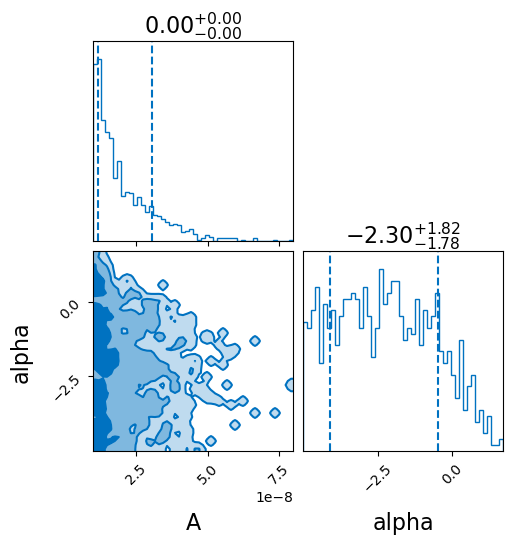

In [12]:
# A few simple setup steps
label = 'GWB_powerlaw'
outdir = 'outdir'

cleanup_dir(outdir)

Amin,Amax,alpha_min,alpha_max=1e-8,1e-3,-5,5
    

fref=25

likelihood = BasicPowerLawGWBLikelihood(Y_f[f_filter],var_f[f_filter],freqs[f_filter],fref)
priors = dict(A=bilby.core.prior.LogUniform(Amin,Amax, 'A'),
              alpha=bilby.core.prior.Uniform(alpha_min,alpha_max, 'alpha'))

# And run sampler
result = bilby.run_sampler(
    likelihood=likelihood, priors=priors, sampler='dynesty', npoints=500,
    walks=10, outdir=outdir, label=label,maxmcmc=10000)
result.plot_corner()

## Noise + CBCs


In [13]:
dat=np.load('../data/colored_noise_plus_signal_H1.npy')
t1,h1=dat[:,0],dat[:,1]
d1=TimeSeries(t1,h1)

dat=np.load('../data/colored_noise_plus_signal_H2.npy')
t2,h2=dat[:,0],dat[:,1]
d2=TimeSeries(t2,h2)

In [14]:
nperseg=int(d1.Fs/deltaF)
freqs,P1_test = welch_psd(d1.data,nperseg=nperseg,window='Hann',fs=d1.Fs)
freqs,P2_test = welch_psd(d2.data,nperseg=nperseg,window='Hann',fs=d2.Fs)

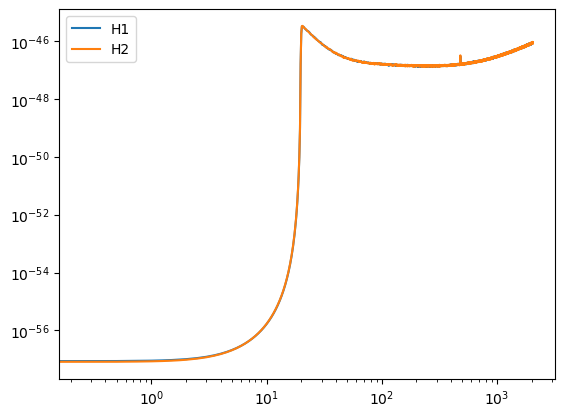

In [15]:
plt.loglog(freqs,P1_test,label='H1')
plt.loglog(freqs,P2_test,label='H2')
plt.legend()

In [16]:
Ys,sigs,Y_fs,var_fs,segmentStartTimes,freqs=stochastic(d1,
                                                       d2,
                                                       segmentDuration,
                                                       deltaF,
                                                       verbose=False,
                                                       doOverlap=True,
                                                       alpha=0,
                                                       fref=25,
                                                       orf_file=None)

/var/folders/h9/8jj76gb51nq2gjkzk76xh3l415264w/T/ipykernel_35141/1520427049.py:108: RuntimeWarning: divide by zero encountered in divide
  S0 = FrequencySeries(freqs, (3*H0**2)/(10*np.pi**2*freqs**3) )
/var/folders/h9/8jj76gb51nq2gjkzk76xh3l415264w/T/ipykernel_35141/1520427049.py:117: ComplexWarning: Casting complex values to real discards the imaginary part
  Ys[II],sigs[II] = calc_Y_sigma_from_Yf_varf(Y_f.data[1:],var_f.data[1:], freqs=freqs[1:], alpha=alpha, fref=fref)
/var/folders/h9/8jj76gb51nq2gjkzk76xh3l415264w/T/ipykernel_35141/1520427049.py:119: ComplexWarning: Casting complex values to real discards the imaginary part
  Y_fs[:,II],var_fs[:,II] = Y_f.data, var_f.data


In [17]:
# combine spectra over times

Y_f,var_f=postprocessing_spectra(Y_fs,var_fs,jobDuration,segmentDuration,
                                 deltaF,d1.deltaT)

/var/folders/h9/8jj76gb51nq2gjkzk76xh3l415264w/T/ipykernel_35141/2966287306.py:14: RuntimeWarning: invalid value encountered in divide
  Y_f_o = np.sum(Y_fs_odds / var_fs_odds,axis=1) / np.sum(1/var_fs_odds,axis=1)
/var/folders/h9/8jj76gb51nq2gjkzk76xh3l415264w/T/ipykernel_35141/2966287306.py:15: RuntimeWarning: divide by zero encountered in divide
  v_f_o = 1/np.sum(1/var_fs_odds,axis=1)
/var/folders/h9/8jj76gb51nq2gjkzk76xh3l415264w/T/ipykernel_35141/2966287306.py:17: RuntimeWarning: invalid value encountered in divide
  Y_f_e = np.sum(Y_fs_evens / var_fs_evens,axis=1) / np.sum(1/var_fs_evens,axis=1)
/var/folders/h9/8jj76gb51nq2gjkzk76xh3l415264w/T/ipykernel_35141/2966287306.py:18: RuntimeWarning: divide by zero encountered in divide
  v_f_e = 1/np.sum(1/var_fs_evens,axis=1)
/var/folders/h9/8jj76gb51nq2gjkzk76xh3l415264w/T/ipykernel_35141/2966287306.py:28: RuntimeWarning: invalid value encountered in subtract
  detC_f = C_f_oo*C_f_ee - C_f_oe**2
/var/folders/h9/8jj76gb51nq2gjkzk76xh3

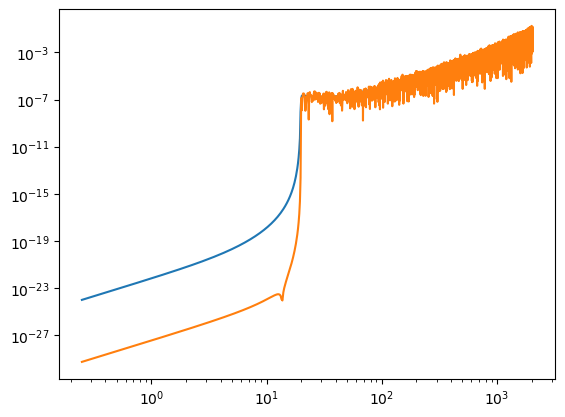

In [18]:
plt.loglog(freqs,np.sqrt(var_f))
plt.loglog(freqs,np.abs(Y_f))

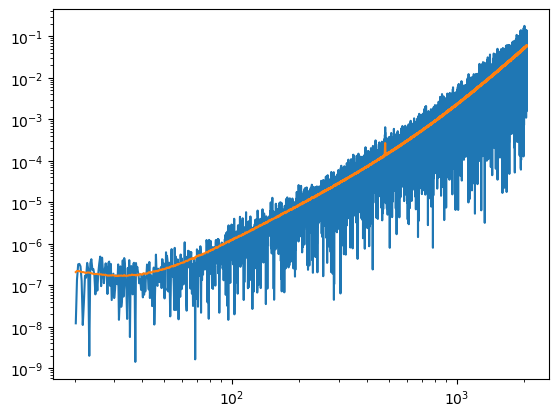

In [19]:
f_filter=freqs>20

plt.loglog(freqs[f_filter],np.abs(Y_f[f_filter]))
plt.loglog(freqs[f_filter],np.sqrt(var_f[f_filter]))


In [20]:
-0.5*(len(freqs[f_filter]))

-4055.5

In [21]:
# compute optimal SNR

y,s=calc_Y_sigma_from_Yf_varf(np.real(Y_f[f_filter]),
                          var_f[f_filter],
                          freqs=freqs[f_filter],
                          alpha=2./3,
                          fref=25)

print('Optimal SNR [alpha=2/3]: %f'%(y/s))


Optimal SNR [alpha=2/3]: 4.564919


Text(0, 0.5, 'SNR')

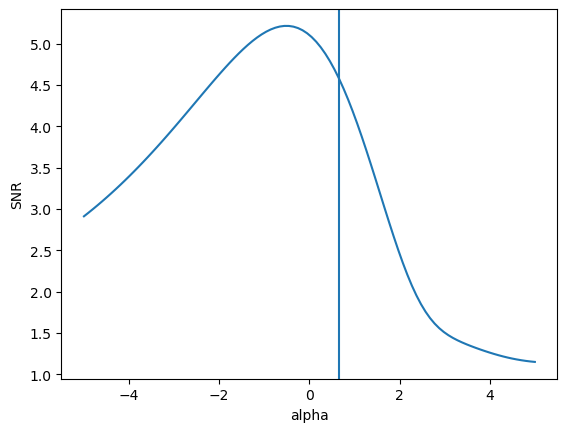

In [22]:
alphas=np.linspace(-5,5,100)

snrs=np.zeros(alphas.shape)
for ii,a in enumerate(alphas):
    y,s=calc_Y_sigma_from_Yf_varf(np.real(Y_f[f_filter]),
                          var_f[f_filter],
                          freqs=freqs[f_filter],
                          alpha=a,
                          fref=25)
    snrs[ii]=y/s
plt.plot(alphas,snrs)
plt.axvline(2./3)
plt.xlabel('alpha')
plt.ylabel('SNR')

14:42 bilby INFO    : Running for label 'GWB_powerlaw', output will be saved to 'outdir'
14:42 bilby INFO    : Analysis priors:
14:42 bilby INFO    : A=LogUniform(minimum=1e-08, maximum=0.001, name='A', latex_label='A', unit=None, boundary=None)
14:42 bilby INFO    : alpha=Uniform(minimum=-5, maximum=5, name='alpha', latex_label='alpha', unit=None, boundary=None)
14:42 bilby INFO    : Analysis likelihood class: <class '__main__.BasicPowerLawGWBLikelihood'>
14:42 bilby INFO    : Analysis likelihood noise evidence: 42857.08347663161
14:42 bilby INFO    : Single likelihood evaluation took 2.996e-04 s
14:42 bilby INFO    : Using sampler Dynesty with kwargs {'nlive': 500, 'bound': 'live', 'sample': 'act-walk', 'periodic': None, 'reflective': None, 'update_interval': 600, 'first_update': None, 'npdim': None, 'rstate': None, 'queue_size': 1, 'pool': None, 'use_pool': None, 'live_points': None, 'logl_args': None, 'logl_kwargs': None, 'ptform_args': None, 'ptform_kwargs': None, 'gradient': None

3701it [00:13, 246.70it/s, bound:68 nc: 25 ncall:6.0e+04 eff:6.2% logz-ratio=8.35+/-0.16 dlogz:0.110>0.1]         

14:42 bilby INFO    : Written checkpoint file outdir/GWB_powerlaw_resume.pickle


3746it [00:15, 240.07it/s, bound:70 nc:  1 ncall:6.1e+04 eff:7.0% logz-ratio=8.46+/-0.09 dlogz:0.000>0.1]

14:42 bilby INFO    : Rejection sampling nested samples to obtain 1468 posterior samples
14:42 bilby INFO    : Sampling time: 0:00:15.599452
14:42 bilby INFO    : Summary of results:
nsamples: 1468
ln_noise_evidence: 42857.083
ln_evidence: 42865.541 +/-  0.114
ln_bayes_factor:  8.458 +/-  0.114



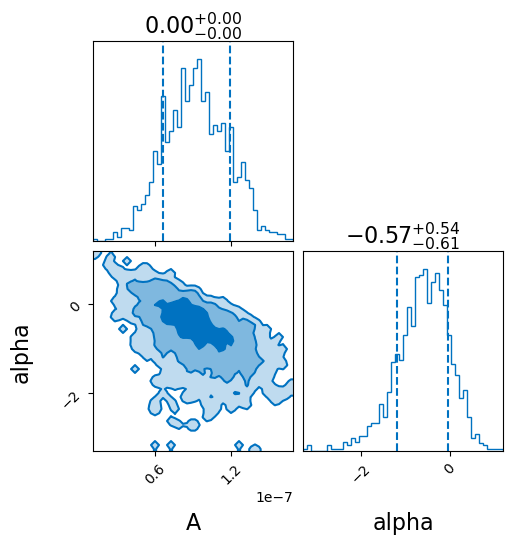

In [23]:
# A few simple setup steps
label = 'GWB_powerlaw'
outdir = 'outdir'

cleanup_dir(outdir)

Amin,Amax,alpha_min,alpha_max=1e-8,1e-3,-5,5
    

fref=25

likelihood = BasicPowerLawGWBLikelihood(Y_f[f_filter],var_f[f_filter],freqs[f_filter],fref)
priors = dict(A=bilby.core.prior.LogUniform(Amin,Amax, 'A'),
              alpha=bilby.core.prior.Uniform(alpha_min,alpha_max, 'alpha'))

# And run sampler
result = bilby.run_sampler(
    likelihood=likelihood, priors=priors, sampler='dynesty', npoints=500,
    walks=10, outdir=outdir, label=label,maxmcmc=10000)
result.plot_corner()

In [24]:
A=result.samples[:,0]
alpha=result.samples[:,1]

Text(0.5, 0, '')

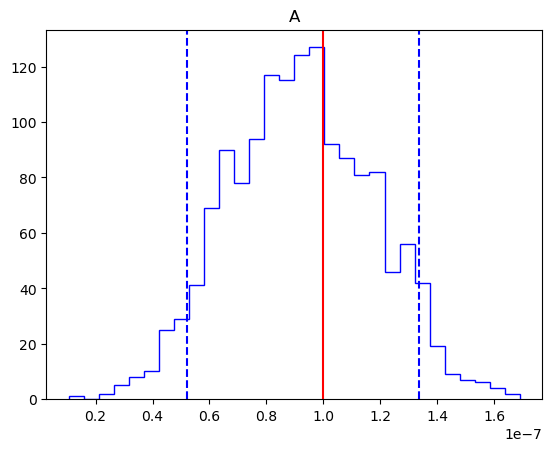

In [25]:
plt.hist(A,bins=30,histtype='step',color='blue')
plt.axvline(np.percentile(A,5),color='blue',linestyle='--')
plt.axvline(np.percentile(A,95),color='blue',linestyle='--')

plt.axvline(1e-7,color='red')

plt.title('A')
plt.xlabel('')

Text(0.5, 0, '')

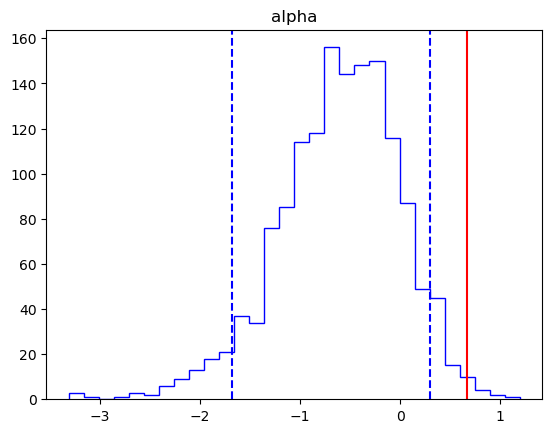

In [26]:
plt.hist(alpha,bins=30,histtype='step',color='blue')
plt.axvline(np.percentile(alpha,5),color='blue',linestyle='--')
plt.axvline(np.percentile(alpha,95),color='blue',linestyle='--')

plt.axvline(2./3,color='red')

plt.title('alpha')
plt.xlabel('')